In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

Year 1:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 24.171849376374965
Year 2:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 23.72973663559568
Year 3:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 23.287619155681934
Year 4:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 22.84549689287333
Year 5:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 22.4033698040907
Year 6:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 21.961237846990066
Year 7:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 21.51910098001862
Year 8:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 21.07695916247269
Year 9:
  Integral of T(t) where T(t) > 0 ºC: 0.0
  Integral of |T(t)| where T(t) < 0 ºC: 20.634812354557873
Year 10:
  Integral of T(

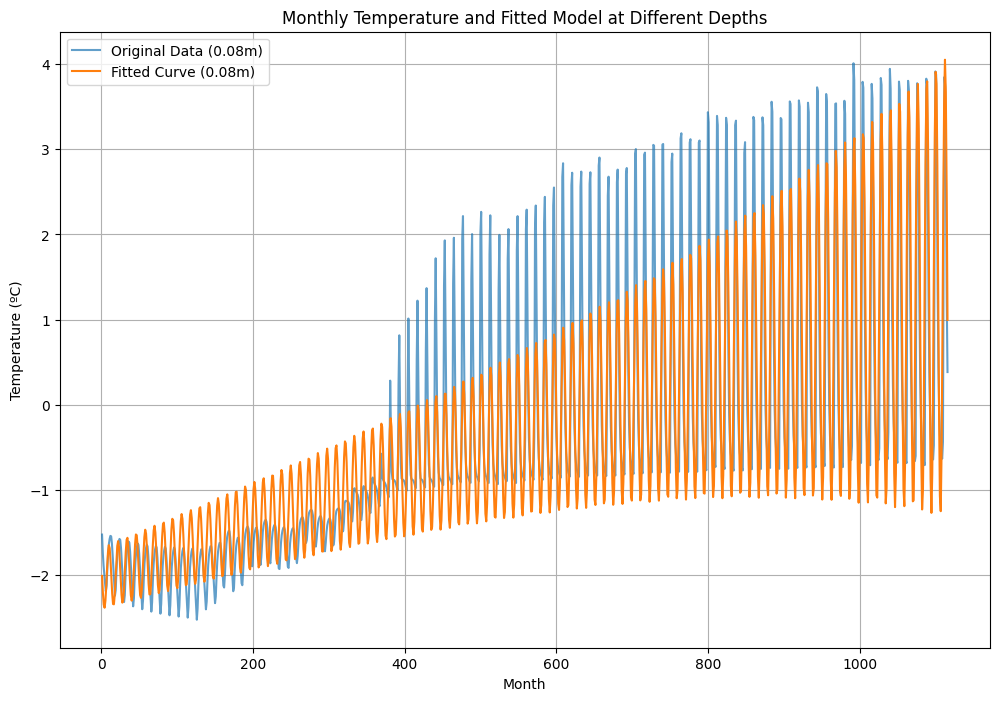

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Define the enhanced model function
def model(x, a, b, c, d, e, f):
    return a * x + b + c * np.exp(d * x) * np.cos(2 * np.pi * e * x + f)

# Load the data
data = np.loadtxt('result_CMIP6_ssp245.txt', skiprows=0, unpack=False)
header = ['id', 'month', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
df = pd.DataFrame(data, columns=header)
months = df['month'].values

# Prepare a figure for plotting
plt.figure(figsize=(12, 8))

# List of depths to plot
depths_to_plot = ['0.08m']  # Specify the depths you want to process

# Process each depth
for depth in depths_to_plot:
    temperatures = df[depth].values
    
    # Fit the enhanced model
    params, _ = curve_fit(model, months, temperatures, p0=[0.1, 25, 1, 0.01, 1/12, 0])
    
    # Generate data for the fitted curve
    x_fit = np.linspace(min(months), max(months), 1000)
    y_fit = model(x_fit, *params)
    
    # Define integrals for positive and negative parts
    def integrate_positive(start_month, end_month):
        def integrand(x):
            y = model(x, *params)
            return y if y > 0 else 0
        return quad(integrand, start_month, end_month)[0]

    def integrate_negative(start_month, end_month):
        def integrand(x):
            y = model(x, *params)
            return -y if y < 0 else 0
        return quad(integrand, start_month, end_month)[0]
    
    # Ensure the number of years is an integer
    num_months = int(max(months) - min(months))
    num_years = num_months // 12
    
    # Calculate and print yearly integrals
    for year in range(num_years):
        start_month = min(months) + year * 12
        end_month = start_month + 12
        
        integral_pos = integrate_positive(start_month, end_month)
        integral_neg = integrate_negative(start_month, end_month)
        
        print(f'Year {year + 1}:')
        print(f'  Integral of T(t) where T(t) > 0 ºC: {integral_pos}')
        print(f'  Integral of |T(t)| where T(t) < 0 ºC: {integral_neg}')
    
    # Handle any remaining months if they don't fit exactly into full years
    if (max(months) - min(months)) % 12 != 0:
        remaining_start = min(months) + num_years * 12
        remaining_end = max(months)
        
        integral_pos = integrate_positive(remaining_start, remaining_end)
        integral_neg = integrate_negative(remaining_start, remaining_end)
        
        print(f'Remaining Period:')
        print(f'  Integral of T(t) where T(t) > 0 ºC: {integral_pos}')
        print(f'  Integral of |T(t)| where T(t) < 0 ºC: {integral_neg}')
    
    # Plot the data and fitted curve
    plt.plot(months, temperatures, '-', label=f'Original Data ({depth})', alpha=0.7)
    plt.plot(x_fit, y_fit, '-', label=f'Fitted Curve ({depth})')

plt.xlabel('Month')
plt.ylabel('Temperature (ºC)')
plt.title('Monthly Temperature and Fitted Model at Different Depths')
plt.legend()
plt.grid(True)
plt.show()
